Importar dependências

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

Carregando dataset

In [24]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 1 columns):
 #   Column                                                                                                                                                                   Non-Null Count  Dtype 
---  ------                                                                                                                                                                   --------------  ----- 
 0   fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"  1599 non-null   object
dtypes: object(1)
memory usage: 12.6+ KB


Dividindo o dataset em features e saída desejada

In [25]:
entrada = df.drop('quality', axis=1)
saida_desejada = df['quality'].values

entrada_train, entrada_test, saida_desejada_train, saida_desejada_test = train_test_split(entrada, saida_desejada, test_size=0.2)

In [27]:
#Scale data
scale = StandardScaler()
entrada_train_padronizados = scale.fit_transform(entrada_train)
entrada_test_padronizados = scale.transform(entrada_test)

Criando modelo

In [127]:
modelo = tf.keras.Sequential()
modelo.add(tf.keras.layers.Dense(units=128, activation='relu', input_shape=(entrada_train.shape[1],)))
modelo.add(tf.keras.layers.Dense(units=64, activation='relu'))
modelo.add(tf.keras.layers.Dense(units=1))
modelo.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 0 (0.00 B)

Compilando e treinando o modelo

In [128]:
modelo.compile(optimizer='Adam', loss='mse')
#optimizer=tf.keras.optimizers.Adam(learning_rate=0.01)

In [129]:
historico = modelo.fit(entrada_train_padronizados, saida_desejada_train, epochs=50, batch_size=32, validation_split=0.2)


Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 19.5843 - val_loss: 7.1377
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.0140 - val_loss: 3.1202
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.4082 - val_loss: 2.1549
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.8710 - val_loss: 1.8483
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.5906 - val_loss: 1.6106
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4012 - val_loss: 1.4325
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2552 - val_loss: 1.3412
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1225 - val_loss: 1.1965
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0182 - val_loss: 1.0634
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9272 - val_loss: 0.9966
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8618 - val_loss: 0.8909
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7799 - val_

Figuras de avaliação do modelo

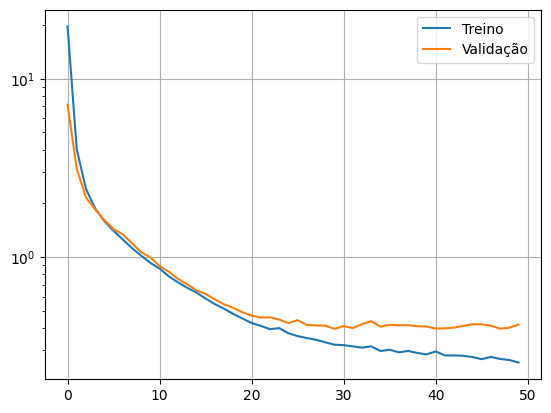

In [130]:
plt.plot(historico.history['loss'], label='Treino')
plt.plot(historico.history['val_loss'], label='Validação')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()

In [42]:
saida_predita = modelo.predict(entrada_test_padronizados)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [43]:
print('MSE: ', mean_squared_error(saida_desejada_test, saida_predita))

MSE:  0.45680299401283264


In [45]:
saida_predita = saida_predita.reshape(saida_predita.shape[0])
print('R2: ', r2_score(saida_desejada_test, saida_predita))

R2:  0.33795732259750366


Teste

In [46]:
dados_de_entrada = np.array([[7.4, 0.70, 0.00, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.9, 5.4]])
dados_de_entrada_padronizados = scale.transform(dados_de_entrada)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [48]:
previsao = modelo.predict(dados_de_entrada_padronizados)
print('Previsão do modelo: ', previsao)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Previsão do modelo:  [[4.556438]]
